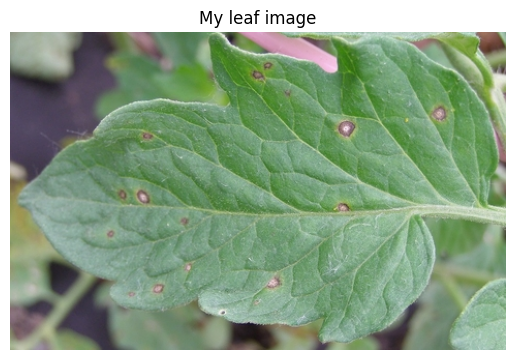

Image size: (480, 308)
Image mode: RGB


In [27]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/leaf.jpg")
plt.imshow(img)
plt.axis("off")
plt.title("My leaf image")
plt.show()

print("Image size:", img.size)
print("Image mode:", img.mode)

In [28]:
import numpy as np

img_array = np.array(img)
print("Shape:", img_array.shape)
print("\nTop-left 5x5 pixels (Red channel only):")
print(img_array[:5, :5, 0])

Shape: (308, 480, 3)

Top-left 5x5 pixels (Red channel only):
[[143 144 148 149 153]
 [142 144 147 149 153]
 [144 144 148 149 152]
 [146 145 148 152 152]
 [146 148 151 152 151]]


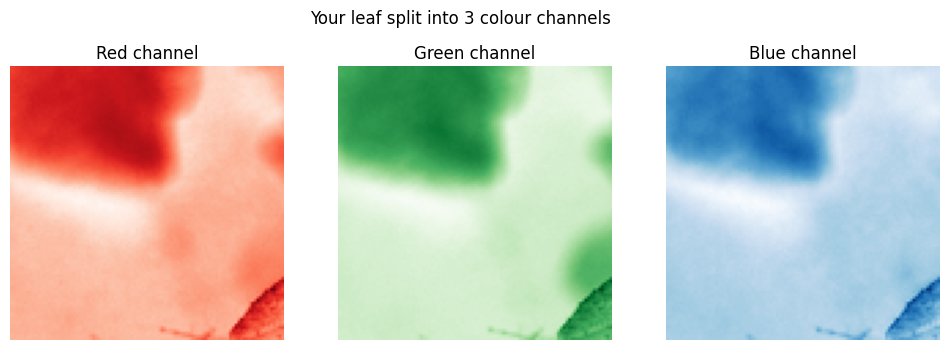

Max value in Green channel: 255
Max value in Red channel: 255
Average Green value: 147.97
Average Red value: 119.43


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

channel_names = ['Red channel', 'Green channel', 'Blue channel']
colors = ['Reds', 'Greens', 'Blues']

for i in range(3):
    axes[i].imshow(img_array[:, :, i], cmap=colors[i])
    axes[i].set_title(channel_names[i])
    axes[i].axis('off')

plt.suptitle("Your leaf split into 3 colour channels")
plt.show()

print("Max value in Green channel:", img_array[:, :, 1].max())
print("Max value in Red channel:", img_array[:, :, 0].max())
print("Average Green value:", img_array[:, :, 1].mean().round(2))
print("Average Red value:", img_array[:, :, 0].mean().round(2))

Original shape: (308, 480, 3)
Resized shape: (224, 224, 3)


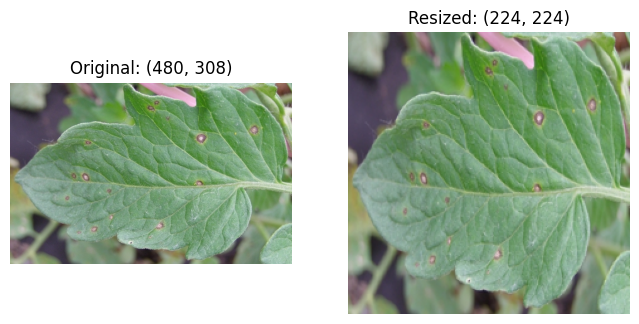

In [35]:
# Resize to 224x224 - the standard input size for most ML models
img_resized = img.resize((224, 224))
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Original: {img.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_resized)
plt.title("Resized: (224, 224)")
plt.axis("off")

plt.show()

In [2]:
import os
import json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "ishwarirautray",
    "key": "KGAT_c42443df0152824059832271ff3ac0e1"
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle configured!")

Kaggle configured!


In [3]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:14<00:00, 150MB/s]



In [4]:
import zipfile

print("Unzipping...")
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Done!")

Unzipping...
Done!


In [5]:
import os

base_path = "plantvillage/raw"
folders = os.listdir(base_path)
print(f"Total disease classes: {len(folders)}")
print("\nFirst 10 classes:")
for folder in sorted(folders)[:10]:
    count = len(os.listdir(os.path.join(base_path, folder)))
    print(f"  {folder}: {count} images")

FileNotFoundError: [Errno 2] No such file or directory: 'plantvillage/raw'

In [6]:
import os

def show_structure(path, indent=0):
    for item in sorted(os.listdir(path))[:5]:
        print("  " * indent + item)
        full = os.path.join(path, item)
        if os.path.isdir(full) and indent < 2:
            show_structure(full, indent + 1)

show_structure("plantvillage")

plantvillage dataset
  color
    Apple___Apple_scab
    Apple___Black_rot
    Apple___Cedar_apple_rust
    Apple___healthy
    Blueberry___healthy
  grayscale
    Apple___Apple_scab
    Apple___Black_rot
    Apple___Cedar_apple_rust
    Apple___healthy
    Blueberry___healthy
  segmented
    Apple___Apple_scab
    Apple___Black_rot
    Apple___Cedar_apple_rust
    Apple___healthy
    Blueberry___healthy


In [7]:
import os

base_path = "plantvillage dataset/color"
folders = os.listdir(base_path)

print(f"Total disease classes: {len(folders)}")
print("\nAll classes:")
for folder in sorted(folders):
    count = len(os.listdir(os.path.join(base_path, folder)))
    print(f"  {folder}: {count} images")

FileNotFoundError: [Errno 2] No such file or directory: 'plantvillage dataset/color'

In [8]:
import os
print(os.listdir("."))

['.config', 'plantvillage', 'plantvillage-dataset.zip', 'sample_data']


In [9]:
import os
print(os.listdir("plantvillage"))

['plantvillage dataset']


In [10]:
import os

base_path = "plantvillage/plantvillage dataset/color"
folders = os.listdir(base_path)

print(f"Total disease classes: {len(folders)}")
print("\nAll classes:")
for folder in sorted(folders):
    count = len(os.listdir(os.path.join(base_path, folder)))
    print(f"  {folder}: {count} images")

Total disease classes: 38

All classes:
  Apple___Apple_scab: 630 images
  Apple___Black_rot: 621 images
  Apple___Cedar_apple_rust: 275 images
  Apple___healthy: 1645 images
  Blueberry___healthy: 1502 images
  Cherry_(including_sour)___Powdery_mildew: 1052 images
  Cherry_(including_sour)___healthy: 854 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn_(maize)___Common_rust_: 1192 images
  Corn_(maize)___Northern_Leaf_Blight: 985 images
  Corn_(maize)___healthy: 1162 images
  Grape___Black_rot: 1180 images
  Grape___Esca_(Black_Measles): 1383 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
  Grape___healthy: 423 images
  Orange___Haunglongbing_(Citrus_greening): 5507 images
  Peach___Bacterial_spot: 2297 images
  Peach___healthy: 360 images
  Pepper,_bell___Bacterial_spot: 997 images
  Pepper,_bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Raspberry___h

In [11]:
total = 0
for folder in folders:
    count = len(os.listdir(os.path.join(base_path, folder)))
    total += count
print(f"Total images in dataset: {total}")

Total images in dataset: 54305


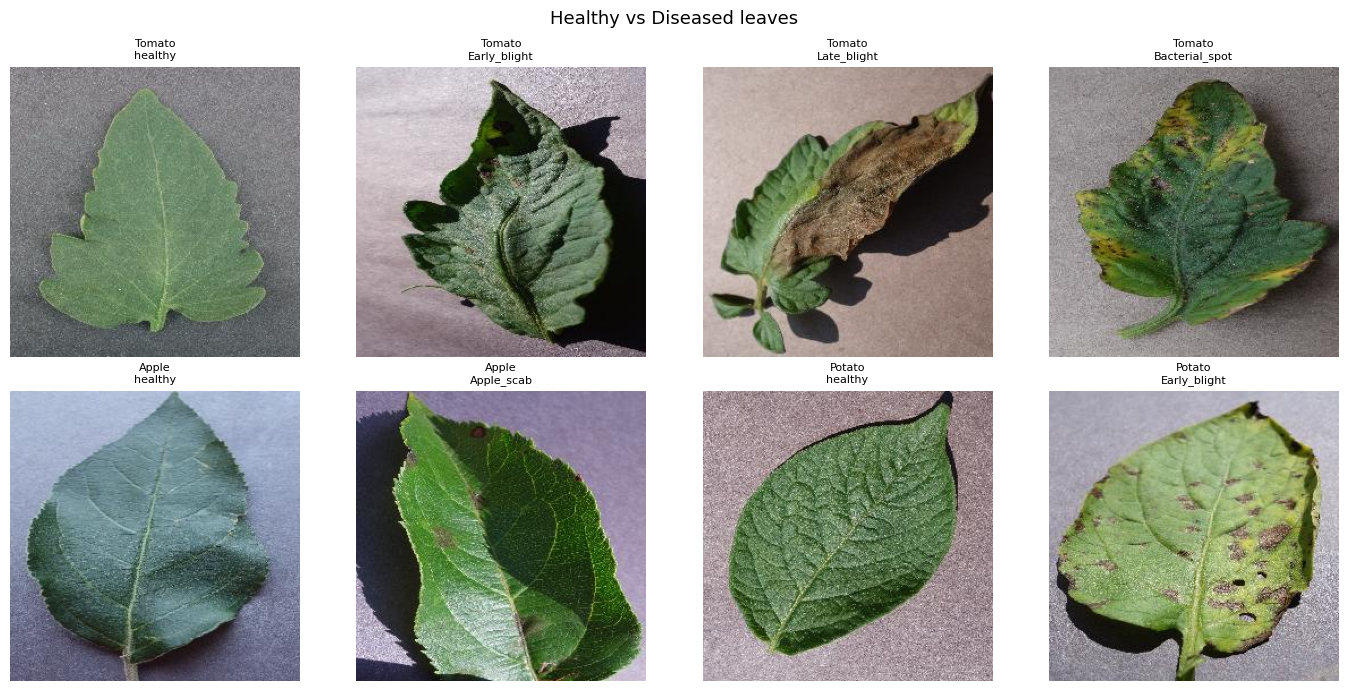

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

classes_to_show = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Bacterial_spot",
    "Apple___healthy",
    "Apple___Apple_scab",
    "Potato___healthy",
    "Potato___Early_blight"
]

for idx, class_name in enumerate(classes_to_show):
    row = idx // 4
    col = idx % 4
    class_path = os.path.join(base_path, class_name)
    img_file = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_file))
    axes[row][col].imshow(img)
    axes[row][col].set_title(class_name.replace("___", "\n"), fontsize=8)
    axes[row][col].axis("off")

plt.suptitle("Healthy vs Diseased leaves", fontsize=13)
plt.tight_layout()
plt.show()

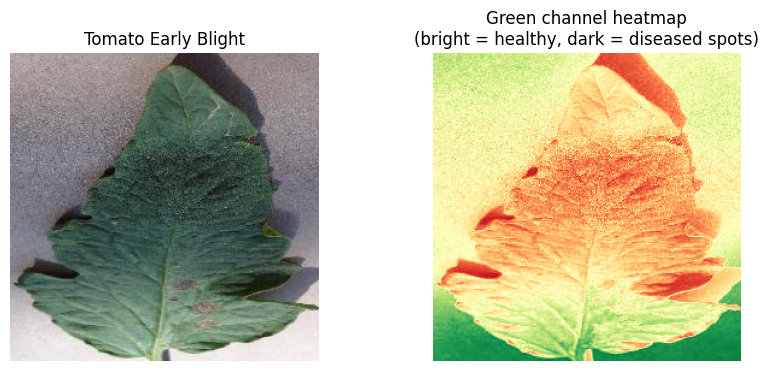

Where disease spots are, Green values drop:
Average green - healthy area (top 10 rows): 130.7
Average green - middle area: 85.5


In [14]:
# Pick one diseased tomato image
import numpy as np
diseased_path = os.path.join(base_path, "Tomato___Early_blight")
img_file = os.listdir(diseased_path)[0]
diseased_img = Image.open(os.path.join(diseased_path, img_file))
diseased_array = np.array(diseased_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Show image
axes[0].imshow(diseased_img)
axes[0].set_title("Tomato Early Blight")
axes[0].axis("off")

# Show green channel heatmap
axes[1].imshow(diseased_array[:,:,1], cmap="RdYlGn")
axes[1].set_title("Green channel heatmap\n(bright = healthy, dark = diseased spots)")
axes[1].axis("off")

plt.show()

print("Where disease spots are, Green values drop:")
print("Average green - healthy area (top 10 rows):",
      diseased_array[:10,:,1].mean().round(1))
print("Average green - middle area:",
      diseased_array[100:150,:,1].mean().round(1))